In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv(
    r"C:\Users\sampa\Desktop\AI-Smart-Shopping-Basket-Optimizer\data\processed\bigbasket_cleaned.csv"
)

In [3]:
df.head()

,product,category,sub_category,brand,sale_price,market_price,type,rating,description
0,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...
1,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ..."
2,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.4,"A perfect gift for all occasions, be it your m..."
3,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.0,176.0,"Laundry, Storage Baskets",3.7,Multipurpose container with an attractive desi...
4,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,162.0,Bathing Bars & Soaps,4.4,Nivea Creme Soft Soap gives your skin the best...


In [4]:
top_categories = df["category"].value_counts().head(10)
top_categories

category
Beauty & Hygiene            7867
Gourmet & World Food        4690
Kitchen, Garden & Pets      3580
Snacks & Branded Foods      2814
Foodgrains, Oil & Masala    2676
Cleaning & Household        2675
Beverages                    885
Bakery, Cakes & Dairy        851
Baby Care                    610
Fruits & Vegetables          557
Name: count, dtype: int64

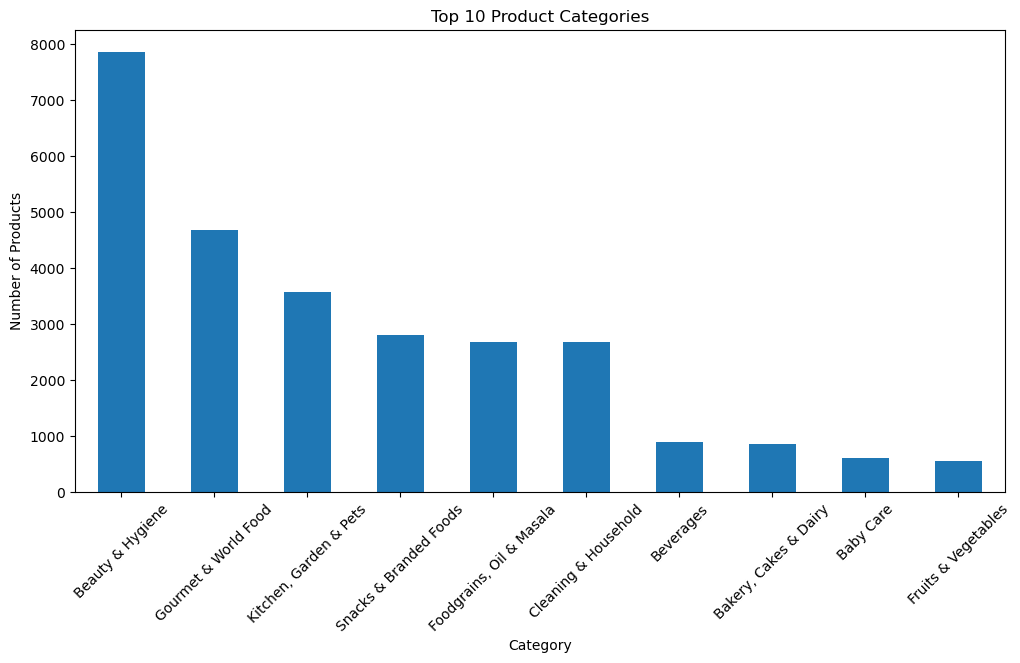

In [5]:
plt.figure(figsize=(12,6))

top_categories.plot(kind="bar")

plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Number of Products")

plt.xticks(rotation=45)

plt.show()

In [6]:
top_brands = df["brand"].value_counts().head(10)
top_brands

brand
Fresho              638
bb Royal            539
BB Home             428
DP                  250
Fresho Signature    171
bb Combo            168
Amul                153
INATUR              146
Himalaya            141
Dabur               138
Name: count, dtype: int64

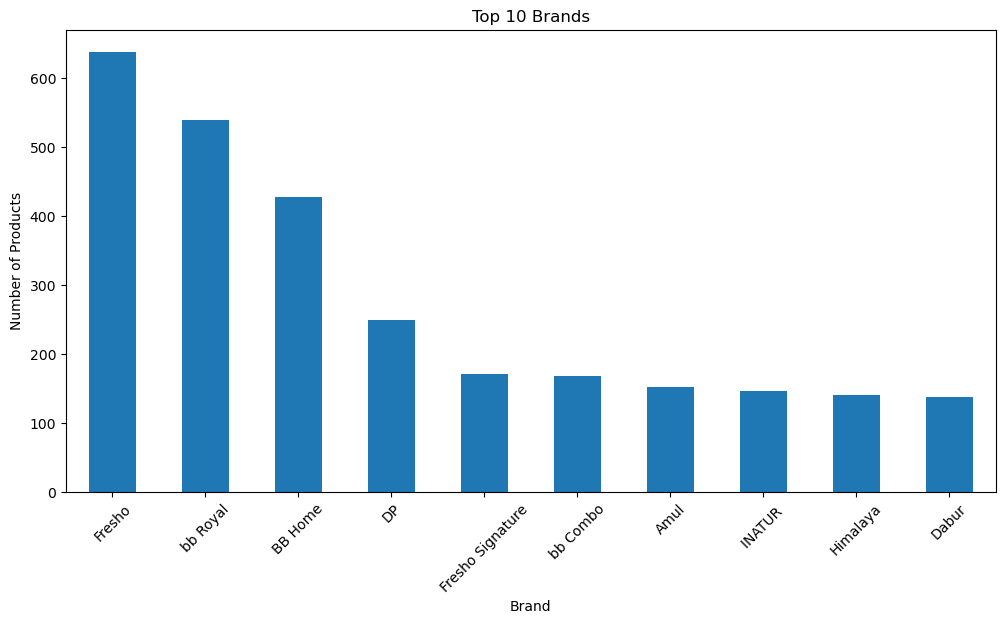

In [7]:
plt.figure(figsize=(12,6))

top_brands.plot(kind="bar")

plt.title("Top 10 Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Products")

plt.xticks(rotation=45)

plt.show()

In [8]:
top_expensive = df.nlargest(10, "sale_price")

top_expensive[["product", "brand", "sale_price", "market_price"]]

,product,brand,sale_price,market_price
25301,Bravura Clipper,Wahl,12500.00,12500.0
21761,Pet Food - N&D Team Breeder Puppy Top Farmina,Farmina,10090.00,10090.0
12669,Epilator SE9-9961 Legs-Body-Face,Braun,8184.44,10769.0
23082,"Gas Stove-4 Burner Royale Plus Schott Glass, B...",Prestige,7999.00,12245.0
2781,Extra Virgin Olive Oil,Abbies,7299.00,7299.0
25797,"4 Burner Gas Stove - Marvel Plus Glass Tables,...",Prestige,7270.00,9695.0
1056,"Gas Stove-3 Burner Royale Plus Schott Glass, B...",Prestige,6999.00,10695.0
6034,Whey Protein Powder,BTN Sports,6700.00,6700.0
1766,Good Girl Eau De Parfum For Women,Carolina Herrera,6660.00,7400.0
5464,Olive Oil - Extra Virgin,Colavita,6500.00,6500.0


In [9]:
cheapest_products = df.nsmallest(10, "sale_price")

cheapest_products[["product", "brand", "sale_price", "market_price"]]

,product,brand,sale_price,market_price
26976,Curry Leaves,Fresho,2.45,15.00
21312,Serum,Livon,3.00,3.00
2761,Orbit Sugar-Free Chewing Gum - Lemon & Lime,Wrigleys,5.00,5.00
2978,Sugar Free Chewing Gum - Mixed Fruit,Orbit,5.00,5.00
3445,Marie Light Biscuits - Active,Sunfeast,5.00,5.00
6014,Good Day Butter Cookies,Britannia,5.00,5.00
9971,"Tomato - Local, Organically Grown",Fresho,5.00,6.25
11306,Happy Happy Choco-Chip Cookies,Parle,5.00,5.00
11435,Exam Standard Scale,Camlin,5.00,5.00
14184,"Tomato - Local, Organically Grown",Fresho,5.00,6.25


In [10]:
df["discount_percent"] = (
    (df["market_price"] - df["sale_price"]) / df["market_price"]
) * 100

In [11]:
df[["product", "sale_price", "market_price", "discount_percent"]].head()

,product,sale_price,market_price,discount_percent
0,Garlic Oil - Vegetarian Capsule 500 mg,220.0,220.0,0.000000
1,Water Bottle - Orange,180.0,180.0,0.000000
2,"Brass Angle Deep - Plain, No.2",119.0,250.0,52.400000
3,Cereal Flip Lid Container/Storage Jar - Assort...,149.0,176.0,15.340909
4,Creme Soft Soap - For Hands & Body,162.0,162.0,0.000000


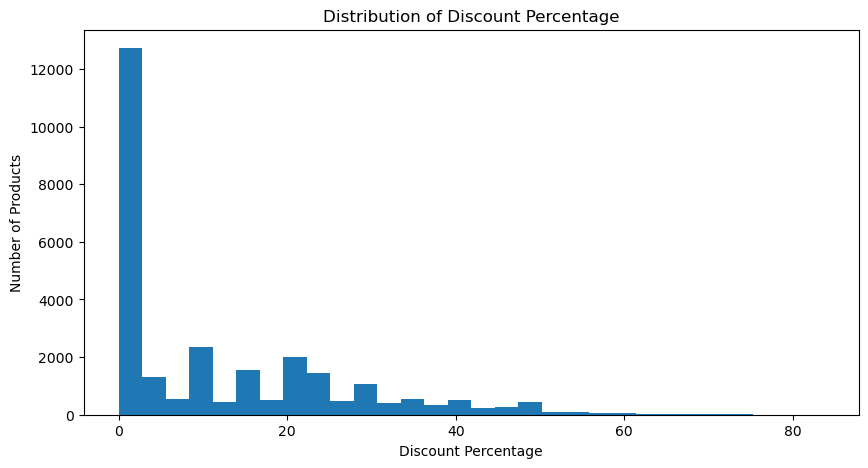

In [12]:
plt.figure(figsize=(10,5))

plt.hist(df["discount_percent"], bins=30)

plt.title("Distribution of Discount Percentage")
plt.xlabel("Discount Percentage")
plt.ylabel("Number of Products")

plt.show()

In [13]:
top_discount = df.nlargest(10, "discount_percent")

top_discount[
    ["product", "brand", "sale_price", "market_price", "discount_percent"]
]

,product,brand,sale_price,market_price,discount_percent
26976,Curry Leaves,Fresho,2.45,15.0,83.666667
17713,Fruit & Vegetables Hand Juicer,Triones,349.00,1995.0,82.506266
13318,Small Silicone Spatula With Plastic Handle - A...,HAZEL,75.00,399.0,81.203008
13740,Decorative Party Light Big Star String LED Lig...,Lexton,209.00,1099.0,80.982712
10438,NHS 860 Temperature Control Professional Hair ...,Nova,467.03,2395.0,80.499791
4562,Concealer Brush 930,Mud,350.00,1750.0,80.000000
11473,Decorative Party Light Golden Bell String LED ...,Lexton,415.00,1999.0,79.239620
13265,Decorative Party Light Golden Bell String LED ...,Lexton,415.00,1999.0,79.239620
10092,USB String Fairy Lights 3M 30 LED For Decorati...,Mansaa,85.00,399.0,78.696742
398,Steel Belly Shape Storage Dabba/ Container Set...,Jensons,219.00,995.0,77.989950


In [14]:
df["rating"].describe()

count    18929.000000
mean         3.943410
std          0.739063
min          1.000000
25%          3.700000
50%          4.100000
75%          4.300000
max          5.000000
Name: rating, dtype: float64

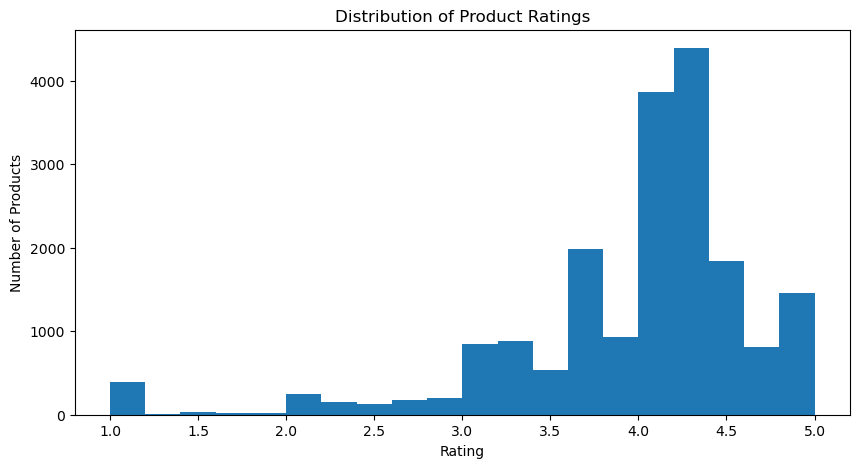

In [15]:
plt.figure(figsize=(10, 5))

plt.hist(df["rating"].dropna(), bins=20)

plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Products")

plt.show()

## Business Insights

1. Beauty & Hygiene is the largest product category in the dataset.
2. Fresho is the most frequently occurring brand.
3. Most products are priced below ₹500.
4. A large number of products have ratings between 4.0 and 4.5.
5. Some products offer discounts of more than 50%, indicating aggressive promotional pricing.

## Conclusion

The exploratory data analysis provided useful insights into product categories, brands, prices, discounts, and customer ratings. These findings will help in building a product recommendation system using machine learning techniques in the next notebook.